In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
df = pd.read_csv("electric_vehicles_spec_2025.csv")
df.head

<bound method NDFrame.head of        brand  ...                                         source_url
0     Abarth  ...  https://ev-database.org/car/1904/Abarth-500e-C...
1     Abarth  ...  https://ev-database.org/car/1903/Abarth-500e-H...
2     Abarth  ...  https://ev-database.org/car/3057/Abarth-600e-S...
3     Abarth  ...  https://ev-database.org/car/3056/Abarth-600e-T...
4     Aiways  ...         https://ev-database.org/car/1678/Aiways-U5
..       ...  ...                                                ...
473    Zeekr  ...  https://ev-database.org/car/3081/Zeekr-7X-Prem...
474    Zeekr  ...  https://ev-database.org/car/3197/Zeekr-X-Core-RWD
475    Zeekr  ...  https://ev-database.org/car/3198/Zeekr-X-Long-...
476    Zeekr  ...  https://ev-database.org/car/3199/Zeekr-X-Privi...
477  firefly  ...   https://ev-database.org/car/3178/firefly-firefly

[478 rows x 22 columns]>

In [3]:
df.shape

(478, 22)

In [4]:
df.describe

<bound method NDFrame.describe of        brand  ...                                         source_url
0     Abarth  ...  https://ev-database.org/car/1904/Abarth-500e-C...
1     Abarth  ...  https://ev-database.org/car/1903/Abarth-500e-H...
2     Abarth  ...  https://ev-database.org/car/3057/Abarth-600e-S...
3     Abarth  ...  https://ev-database.org/car/3056/Abarth-600e-T...
4     Aiways  ...         https://ev-database.org/car/1678/Aiways-U5
..       ...  ...                                                ...
473    Zeekr  ...  https://ev-database.org/car/3081/Zeekr-7X-Prem...
474    Zeekr  ...  https://ev-database.org/car/3197/Zeekr-X-Core-RWD
475    Zeekr  ...  https://ev-database.org/car/3198/Zeekr-X-Long-...
476    Zeekr  ...  https://ev-database.org/car/3199/Zeekr-X-Privi...
477  firefly  ...   https://ev-database.org/car/3178/firefly-firefly

[478 rows x 22 columns]>

In [5]:
features = ['top_speed_kmh', 'battery_capacity_kWh', 'range_km',
'efficiency_wh_per_km', 'acceleration_0_100_s', 'fast_charging_power_kw_dc']

df = df.dropna(subset=features)
print("Rows after dropping :", len(df))

Rows after dropping : 477


In [6]:
X = df[features]
X

,top_speed_kmh,battery_capacity_kWh,range_km,efficiency_wh_per_km,acceleration_0_100_s,fast_charging_power_kw_dc
0,155,37.8,225,156,7.0,67.0
1,155,37.8,225,149,7.0,67.0
2,200,50.8,280,158,5.9,79.0
3,200,50.8,280,158,6.2,79.0
4,150,60.0,315,156,7.5,78.0
...,...,...,...,...,...,...
473,210,71.0,365,148,6.0,240.0
474,190,49.0,265,148,5.9,70.0
475,190,65.0,360,146,5.6,114.0
476,190,65.0,350,153,3.8,114.0


In [7]:
X.columns

Index(['top_speed_kmh', 'battery_capacity_kWh', 'range_km',
       'efficiency_wh_per_km', 'acceleration_0_100_s',
       'fast_charging_power_kw_dc'],
      dtype='object')

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
Z = linkage(X_scaled, method='ward')
Z.shape

(476, 4)

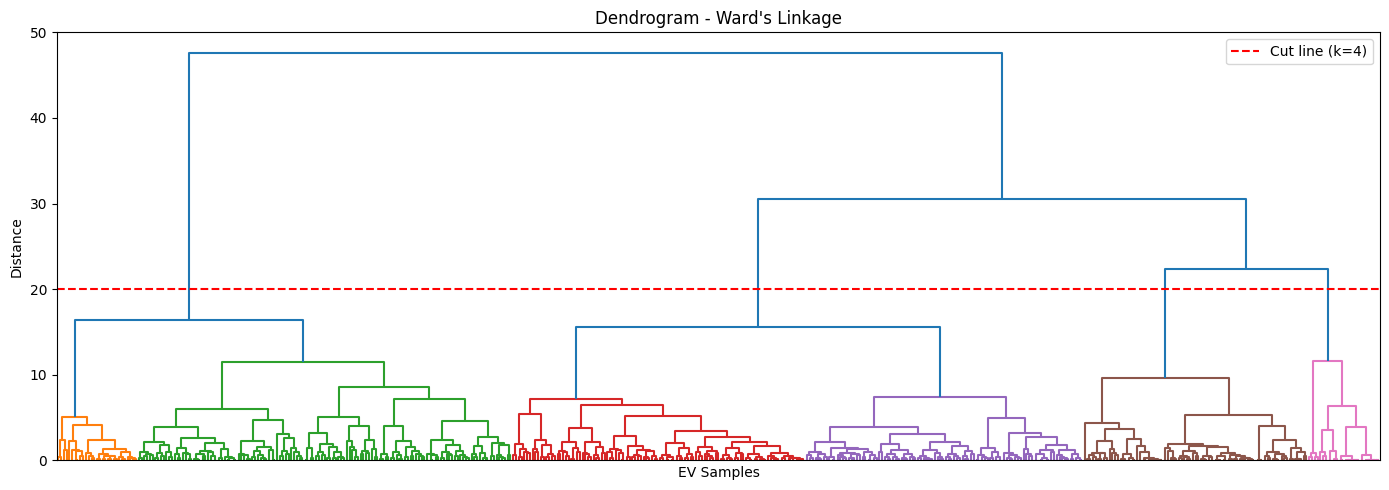

In [10]:
plt.figure(figsize=(14, 5))
dendrogram(Z, no_labels=True, color_threshold=12)
plt.axhline(y=20, color='red', linestyle='--', label='Cut line (k=4)')
plt.title("Dendrogram - Ward's Linkage")
plt.xlabel("EV Samples")
plt.ylabel("Distance")
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
model = AgglomerativeClustering(n_clusters=4, linkage='ward')
df['cluster'] = model.fit_predict(X_scaled)
print("\nCluster counts:")
print(df['cluster'].value_counts())


Cluster counts:
cluster
2    206
0    164
3     81
1     26
Name: count, dtype: int64


C:\Users\Shruti\AppData\Local\Temp\ipykernel_33460\842313014.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster'] = model.fit_predict(X_scaled)


In [13]:
score = silhouette_score(X_scaled, df['cluster'])
print(f"Silhouette Score : {score:.4f}")

Silhouette Score : 0.2990


In [14]:
print("Cluster Mean Profiles : ")
print(df.groupby('cluster')[features].mean().round(2))

Cluster Mean Profiles : 
         top_speed_kmh  ...  fast_charging_power_kw_dc
cluster                 ...                           
0               221.02  ...                     178.09
1               138.85  ...                      76.38
2               178.01  ...                     111.22
3               148.21  ...                      68.21

[4 rows x 6 columns]


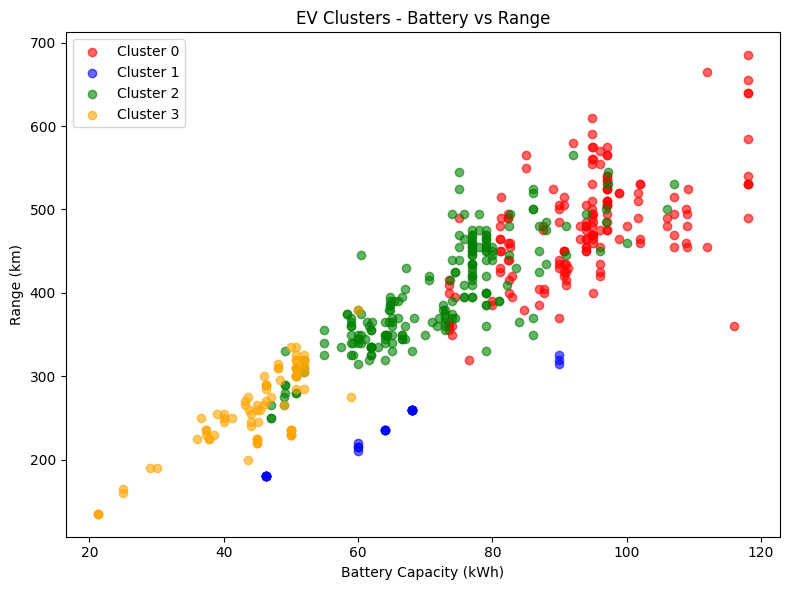

In [15]:
colors = ['red', 'blue', 'green', 'orange']
plt.figure(figsize=(8, 6))
for c in range(4):
    subset = df[df['cluster'] == c]
    plt.scatter(subset['battery_capacity_kWh'], subset['range_km'], label=f'Cluster {c}', color=colors[c], alpha=0.6)
plt.xlabel("Battery Capacity (kWh)")
plt.ylabel("Range (km)")
plt.title("EV Clusters - Battery vs Range")
plt.legend()
plt.tight_layout()
plt.show()